--- Calibration Samples ---
Sample 1: Sensor=850, Wet=155g, Dry=150g -> GSM=3.33%
Sample 2: Sensor=500, Wet=175g, Dry=150g -> GSM=16.67%
Sample 3: Sensor=250, Wet=195g, Dry=150g -> GSM=30.00%
Sample 4: Sensor=100, Wet=210g, Dry=150g -> GSM=40.00%


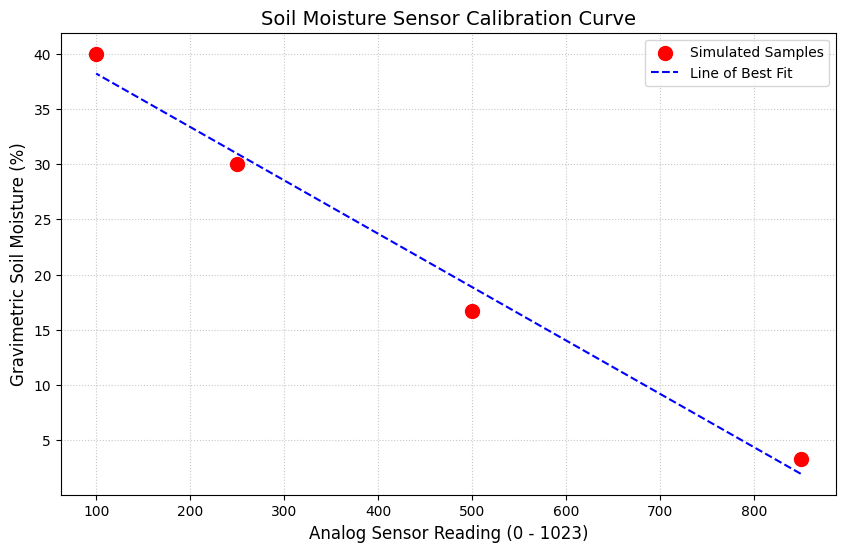


--- Calibrated Reading (Simulated with fixed value) ---
If the live sensor outputs a reading of 420:
The calibrated Gravimetric Soil Moisture is 22.74%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. The Simulated Hardware Data
# Sensor readings (0-1023 scale, higher = drier)
sensor_readings = np.array([850, 500, 250, 100])

# Simulated weights in grams
w_wet = np.array([155, 175, 195, 210])
w_dry = 150  # Assuming 150g of dry base soil was used for each test

# 2. Calculate Gravimetric Soil Moisture (GSM)
# Formula: ((W_wet - W_dry) / W_dry) * 100
gsm_percentages = (w_wet - w_dry) / w_dry * 100

print("--- Calibration Samples ---")
for i in range(len(sensor_readings)):
    print(f"Sample {i+1}: Sensor={sensor_readings[i]}, Wet={w_wet[i]}g, Dry={w_dry}g -> GSM={gsm_percentages[i]:.2f}%")

# 3. Calculate Line of Best Fit (Linear Regression)
m, b = np.polyfit(sensor_readings, gsm_percentages, 1)

# 4. Plot the Graph
plt.figure(figsize=(10, 6))
plt.scatter(sensor_readings, gsm_percentages, color='red', s=100, zorder=5, label='Simulated Samples')
plt.plot(sensor_readings, m * sensor_readings + b, color='blue', linestyle='--', label='Line of Best Fit')

plt.title('Soil Moisture Sensor Calibration Curve', fontsize=14)
plt.xlabel('Analog Sensor Reading (0 - 1023)', fontsize=12)
plt.ylabel('Gravimetric Soil Moisture (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 5. Make a Calibrated Reading
test_sensor_value = 420
calibrated_gsm = (m * test_sensor_value) + b

print("\n--- Calibrated Reading (Simulated with fixed value) ---")
print(f"If the live sensor outputs a reading of {test_sensor_value}:")
print(f"The calibrated Gravimetric Soil Moisture is {calibrated_gsm:.2f}%")